# Pull Data

## Imports

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('.')

from functions.fn_clean import (
    standardize_column_names,
    drop_structural_columns,
    fix_column_types,
    impute_column,
    cap_outliers_iqr,
    transform_skewed_column,
    bin_rare_categories,
    merge_tables,
)
from functions.fn_explore import (
    summarize_dataframe,
    describe_column,
    rank_features_for_target,
    get_correlation_matrix,
    test_relationship,
    compute_target_rate_by_category,
)
from functions.fn_plot import (
    plot_missing_heatmap,
    plot_distributions_all,
    plot_distribution,
    plot_target_rate,
    plot_scatter,
    plot_boxplot,
    plot_correlation_heatmap,
    plot_bivariate_summary,
)

## Load Raw Data

In [25]:
supporters = pd.read_csv('data/supporters.csv')
donations  = pd.read_csv('data/donations.csv')

print(f"supporters shape: {supporters.shape}")
print(f"donations shape:  {donations.shape}")
supporters.head()

supporters shape: (60, 15)
donations shape:  (420, 13)


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01 00:00:00,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06 00:00:00,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11 00:00:00,2023-06-25,SocialMedia
3,4,MonetaryDonor,Liam Diaz,NaN,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,+63 945 516 8956,Active,2022-01-16 00:00:00,2026-03-01,Church
4,5,InKindDonor,Emma Evans,NaN,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,+63 995 371 8454,Active,2022-01-21 00:00:00,2024-01-18,Website


## First Look

In [26]:
print(supporters.dtypes)
print()
print(supporters.info())

supporter_id           int64
supporter_type           str
display_name             str
organization_name        str
first_name               str
last_name                str
relationship_type        str
region                   str
country                  str
email                    str
phone                    str
status                   str
created_at               str
first_donation_date      str
acquisition_channel      str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   supporter_id         60 non-null     int64
 1   supporter_type       60 non-null     str  
 2   display_name         60 non-null     str  
 3   organization_name    4 non-null      str  
 4   first_name           56 non-null     str  
 5   last_name            56 non-null     str  
 6   relationship_type    60 non-null     str  
 7   region               

# Univariate Summary

## Full Univariate Summary

In [27]:
# The unit of analysis here is ONE ROW PER SUPPORTER.
# We are NOT yet looking at donation behavior — that comes after we
# aggregate donations and join them in. First understand what we know
# about each supporter from the supporters table alone.
#
# Things to watch for:
#   - organization_name / first_name / last_name: mutually exclusive nulls
#     (individuals have first/last, orgs have org_name) — these are structural
#   - first_donation_date: null if they've never donated — intentional
#   - display_name, email, phone: PII identifiers — must be dropped

num_df, cat_df = summarize_dataframe(supporters)


  NUMERIC COLUMNS (1)
              dtype  count  missing  missing_pct  min   max  mean  median      std  skew  kurt
column                                                                                        
supporter_id  int64     60        0          0.0  1.0  60.0  30.5    30.5  17.4642   0.0  -1.2

  CATEGORICAL COLUMNS (14)
                    dtype  count  missing  missing_pct  unique                    mode
column                                                                                
supporter_type        str     60        0         0.00       6           MonetaryDonor
display_name          str     60        0         0.00      60              Aria Brown
organization_name     str      4       56        93.33       4       Bright Foundation
first_name            str     56        4         6.67      56                    Aria
last_name             str     56        4         6.67      55                      Xu
relationship_type     str     60        0         0.00 

## Missing Value Map

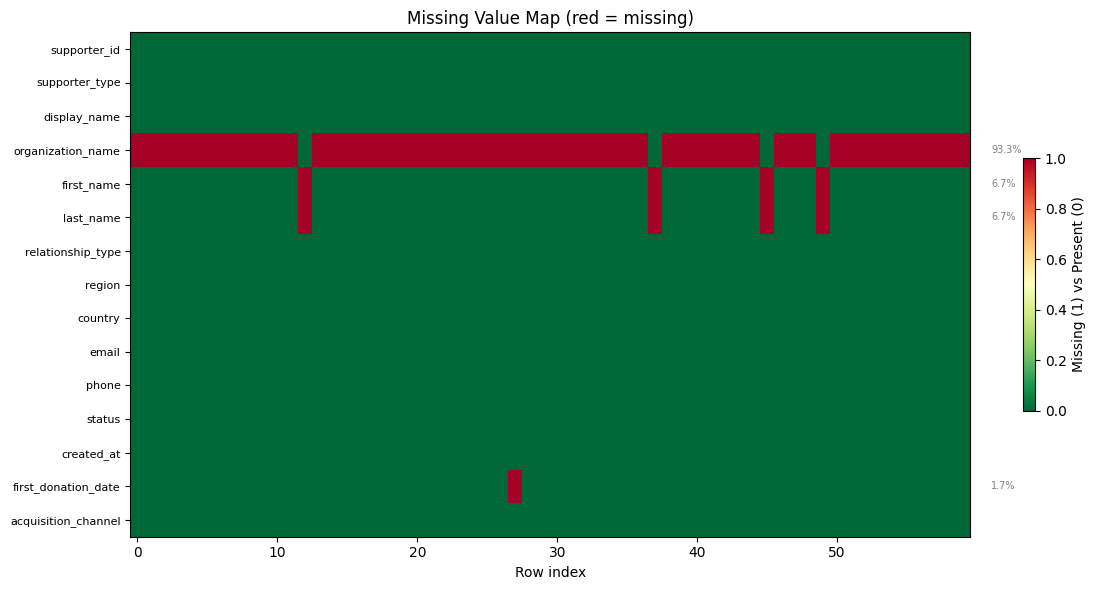

In [28]:
# Expect to see structural null patterns:
#   organization_name: null for all individual supporters
#   first_name / last_name: null for all organization supporters
#   first_donation_date: null for supporters who haven't donated yet

plot_missing_heatmap(supporters)

## Drop Structural Columns

In [29]:
# Drop PII and identifier columns that can never be model features:
#   supporter_id   — primary key, used only as join key (kept in raw)
#   display_name   — PII, name string
#   organization_name — PII / redundant with supporter_type
#   first_name / last_name — PII
#   email / phone  — PII contact info
#   created_at     — record creation timestamp, not useful for modeling
#
# We keep supporter_id in the raw data until after the join, then drop it.

supporters_clean = drop_structural_columns(supporters, [
    'display_name',
    'organization_name',
    'first_name',
    'last_name',
    'email',
    'phone',
])

[drop_structural_columns] Dropped 6 columns: ['display_name', 'organization_name', 'first_name', 'last_name', 'email', 'phone']


## Fix Types and Parse Dates

In [30]:
supporters_clean = fix_column_types(supporters_clean)

# first_donation_date is useful — parse it to extract days_since_first_donation
# which tells us how long a supporter has been active
supporters_clean['first_donation_date'] = pd.to_datetime(
    supporters_clean['first_donation_date'], errors='coerce'
)
supporters_clean['created_at'] = pd.to_datetime(
    supporters_clean['created_at'], errors='coerce'
)

# Days since first donation (tenure as a donor)
import numpy as np
ref_date = pd.Timestamp('today')
supporters_clean['days_since_first_donation'] = (
    ref_date - supporters_clean['first_donation_date']
).dt.days

# Days since record was created (how long they've been in the system)
supporters_clean['days_since_created'] = (
    ref_date - supporters_clean['created_at']
).dt.days

# Drop the raw date columns — can't go into a model
supporters_clean = supporters_clean.drop(
    columns=['first_donation_date', 'created_at']
)

print("Engineered: days_since_first_donation, days_since_created")
print(supporters_clean[['days_since_first_donation', 'days_since_created']].describe())

Engineered: days_since_first_donation, days_since_created
       days_since_first_donation  days_since_created
count                  59.000000           60.000000
mean                  631.220339         1409.500000
std                   344.556740           87.321246
min                    37.000000         1262.000000
25%                   342.500000         1335.750000
50%                   612.000000         1409.500000
75%                   925.000000         1483.250000
max                  1184.000000         1557.000000


## Handle Structural Nulls in Supporters

In [31]:
# days_since_first_donation will be null for supporters who have never donated.
# This is meaningful — null means "no donation history."
# Fill with a large sentinel value (e.g. -1 or 9999) so the model can
# distinguish "never donated" from "donated recently."
# We use -1 here as a flag: "this person has no donation history."

supporters_clean['days_since_first_donation'] = (
    supporters_clean['days_since_first_donation'].fillna(-1)
)

print(supporters_clean.isnull().sum()[supporters_clean.isnull().sum() > 0])

Series([], dtype: int64)


## Explore Donation Behavior

In [32]:
# Now look at the donations table before joining.
# We need to understand what we're aggregating — each donor can have
# many donation events of different types.

print(donations.dtypes)
print()
print(f"Unique supporters in donations: {donations['supporter_id'].nunique()}")
print(f"Donation types:\n{donations['donation_type'].value_counts()}")
print(f"\nChannel sources:\n{donations['channel_source'].value_counts()}")
print(f"\nAmount stats (monetary only):")
print(donations[donations['donation_type'] == 'Monetary']['amount'].describe())

donation_id           int64
supporter_id          int64
donation_type           str
donation_date           str
is_recurring           bool
campaign_name           str
channel_source          str
currency_code           str
amount              float64
estimated_value     float64
impact_unit             str
notes                   str
referral_post_id    float64
dtype: object

Unique supporters in donations: 59
Donation types:
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64

Channel sources:
channel_source
Campaign           119
Event               89
Direct              82
SocialMedia         78
PartnerReferral     52
Name: count, dtype: int64

Amount stats (monetary only):
count     234.00000
mean     1028.73735
std       767.59608
min       250.00000
25%       482.50750
50%       819.63000
75%      1333.15500
max      6481.54000
Name: amount, dtype: float64


## Aggregate Donation Features Per Supporter

In [33]:
# We need one row per supporter for modeling.
# Aggregate from donations → supporter-level behavioral features.
#
# These are the features that describe WHAT A DONOR HAS DONE:
#   total_donations          — total number of donation events
#   monetary_donation_count  — how many times they gave money
#   total_monetary_value     — total pesos given
#   avg_monetary_gift        — average gift size
#   is_recurring_donor       — have they ever set up a recurring gift?
#   unique_campaigns         — how many campaigns they've participated in
#   days_since_last_donation — recency (most important for lapse prediction)
#   donation_types_count     — breadth of engagement (money + time + skills?)

ref_date = pd.Timestamp('today')

monetary = donations[donations['donation_type'] == 'Monetary']

donation_agg = donations.groupby('supporter_id').agg(
    total_donations         =('donation_id',     'count'),
    monetary_donation_count =('donation_type',   lambda x: (x == 'Monetary').sum()),
    total_monetary_value    =('amount',           'sum'),
    avg_monetary_gift       =('amount',           'mean'),
    is_recurring_donor      =('is_recurring',     'max'),
    unique_campaigns        =('campaign_name',    'nunique'),
    last_donation_date      =('donation_date',    'max'),
    donation_types_count    =('donation_type',    'nunique'),
).reset_index()

donation_agg['last_donation_date'] = pd.to_datetime(
    donation_agg['last_donation_date'], errors='coerce'
)
donation_agg['days_since_last_donation'] = (
    ref_date - donation_agg['last_donation_date']
).dt.days

donation_agg = donation_agg.drop(columns=['last_donation_date'])
donation_agg['total_monetary_value'] = donation_agg['total_monetary_value'].fillna(0)
donation_agg['avg_monetary_gift']    = donation_agg['avg_monetary_gift'].fillna(0)

print(f"Aggregated donation features for {len(donation_agg)} supporters")
donation_agg.head()

Aggregated donation features for 59 supporters


,supporter_id,total_donations,monetary_donation_count,total_monetary_value,avg_monetary_gift,is_recurring_donor,unique_campaigns,donation_types_count,days_since_last_donation
0,1,12,7,7567.97,1081.138571,True,2,3,47
1,2,4,2,3480.08,1740.040000,False,0,3,334
2,3,16,9,9225.71,1025.078889,True,3,4,206
3,4,11,8,8694.73,1086.841250,True,3,2,37
4,5,5,4,4738.58,1184.645000,False,1,2,187


## Merge Supporters + Donation Aggregates

In [34]:
# Left join: keep ALL supporters, add donation behavior where it exists.
# Supporters with no donations at all get NaN → fill with 0.

df = merge_tables(supporters_clean, donation_agg, on='supporter_id', how='left')

# Supporters with no donation history
df['total_donations']          = df['total_donations'].fillna(0).astype(int)
df['monetary_donation_count']  = df['monetary_donation_count'].fillna(0).astype(int)
df['total_monetary_value']     = df['total_monetary_value'].fillna(0)
df['avg_monetary_gift']        = df['avg_monetary_gift'].fillna(0)
df['is_recurring_donor']       = df['is_recurring_donor'].fillna(False)
df['unique_campaigns']         = df['unique_campaigns'].fillna(0).astype(int)
df['donation_types_count']     = df['donation_types_count'].fillna(0).astype(int)
df['days_since_last_donation'] = df['days_since_last_donation'].fillna(-1)

# Drop supporter_id — no longer needed as join key
df = df.drop(columns=['supporter_id'])

print(f"Final shape: {df.shape}")
print(f"Supporters with at least one donation: {(df['total_donations'] > 0).sum()}")
print(f"Supporters with no donations: {(df['total_donations'] == 0).sum()}")

[merge_tables] LEFT JOIN on 'supporter_id': 60 rows → 60 rows
Final shape: (60, 16)
Supporters with at least one donation: 59
Supporters with no donations: 1


## Engineer the Pipeline Targets

In [35]:
# Target 1: is_lapsed
# A donor is "lapsed" if they donated at some point but haven't donated
# in the last 365 days. This is the core retention question.
# Only applies to supporters who have donated at least once.

df['is_lapsed'] = (
    (df['total_donations'] > 0) &
    (df['days_since_last_donation'] > 365)
).astype(int)

# Target 2: will_upgrade
# Did a donor give more than their average in their most recent gift?
# A rough proxy for "upsell potential" — who might give more if asked?
# We'll engineer this more carefully but start with a binary flag.
# Requires joining back to individual donations — simplified here.

# Target 3: total_monetary_value (regression)
# Predict total lifetime giving — useful for donor segmentation and
# prioritizing outreach to high-value lapsed donors.

print(f"is_lapsed: {df['is_lapsed'].sum()} lapsed donors "
      f"({df['is_lapsed'].mean():.1%} of all supporters)")
print(f"total_monetary_value mean: {df['total_monetary_value'].mean():.0f} PHP")
print(f"total_monetary_value median: {df['total_monetary_value'].median():.0f} PHP")

is_lapsed: 11 lapsed donors (18.3% of all supporters)
total_monetary_value mean: 4012 PHP
total_monetary_value median: 3049 PHP


## Check Rare Categories

In [36]:
# Check all categorical columns for rare categories before plotting
for col in ['supporter_type', 'relationship_type', 'region',
            'country', 'status', 'acquisition_channel']:
    counts = df[col].value_counts(normalize=True).round(3)
    print(f"\n{col}:\n{counts.to_string()}")


supporter_type:
supporter_type
MonetaryDonor          0.283
InKindDonor            0.250
SocialMediaAdvocate    0.167
Volunteer              0.133
SkillsContributor      0.100
PartnerOrganization    0.067

relationship_type:
relationship_type
Local                  0.567
PartnerOrganization    0.233
International          0.200

region:
region
Luzon       0.517
Mindanao    0.300
Visayas     0.183

country:
country
Philippines    0.800
USA            0.167
Singapore      0.017
Canada         0.017

status:
status
Active      0.75
Inactive    0.25

acquisition_channel:
acquisition_channel
WordOfMouth        0.233
SocialMedia        0.217
Website            0.217
Event              0.133
Church             0.100
PartnerReferral    0.100


### Bin Rare Categories (if needed)

In [37]:
# region and country may have many small values if international donors
# are spread across many countries — bin those below 5%
df = bin_rare_categories(df, 'country', threshold=0.05)
df = bin_rare_categories(df, 'region',  threshold=0.05)

# Re-check
print(df['country'].value_counts())

[bin_rare_categories] 'country' — collapsed 2 rare categories into 'Other': ['Singapore', 'Canada']
[bin_rare_categories] 'region' — no rare categories at 5.0% threshold.
country
Philippines    48
USA            10
Other           2
Name: count, dtype: int64


## Inspect and Handle Skewed Numerics


────────────────────────────────────────────────────
  Column  : total_monetary_value
  Type    : float64  |  Unique: 58
  Count   : 60  |  Missing: 0 (0.0%)
  Range   : 0.0 → 12059.47
  Mean    : 4012.0757  |  Median: 3049.01  |  Std: 3112.4738
  Skew    : 0.8536  |  Kurt: -0.2567
────────────────────────────────────────────────────


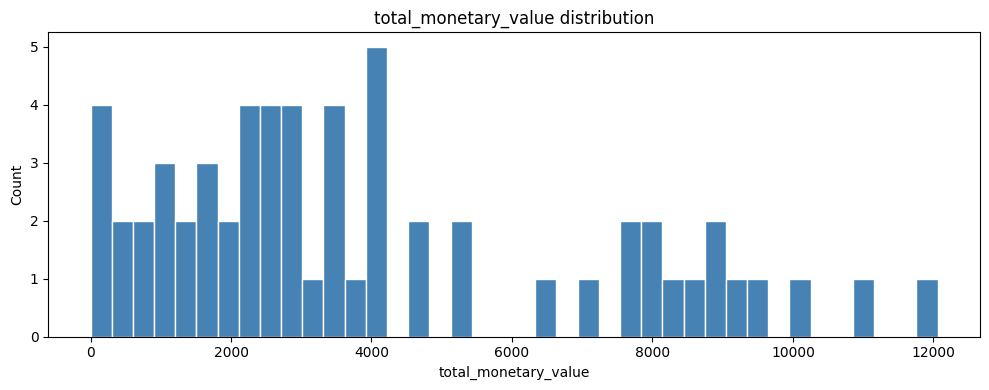


────────────────────────────────────────────────────
  Column  : avg_monetary_gift
  Type    : float64  |  Unique: 58
  Count   : 60  |  Missing: 0 (0.0%)
  Range   : 0.0 → 3014.8675
  Mean    : 1015.9837  |  Median: 978.2689  |  Std: 545.1155
  Skew    : 1.1276  |  Kurt: 2.8351
  ⚠️  High skew (1.13) — consider transform_skewed_column()
────────────────────────────────────────────────────


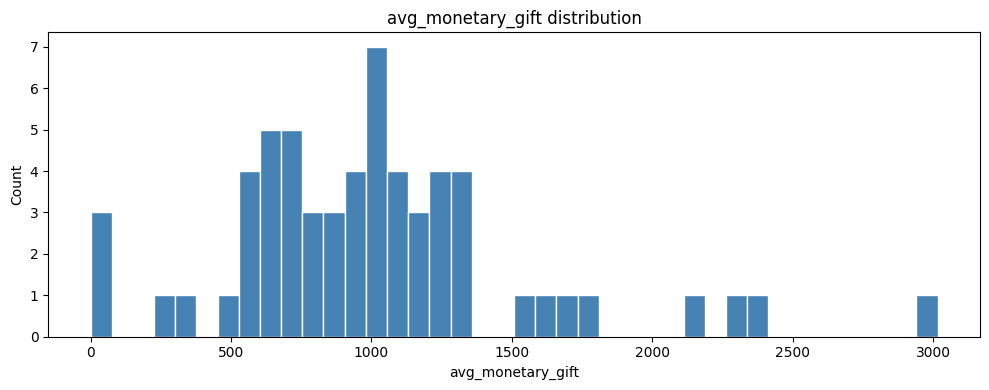


────────────────────────────────────────────────────
  Column  : days_since_last_donation
  Type    : float64  |  Unique: 57
  Count   : 60  |  Missing: 0 (0.0%)
  Range   : -1.0 → 834.0
  Mean    : 218.8167  |  Median: 152.0  |  Std: 187.4965
  Skew    : 1.5808  |  Kurt: 2.3559
  ⚠️  High skew (1.58) — consider transform_skewed_column()
────────────────────────────────────────────────────


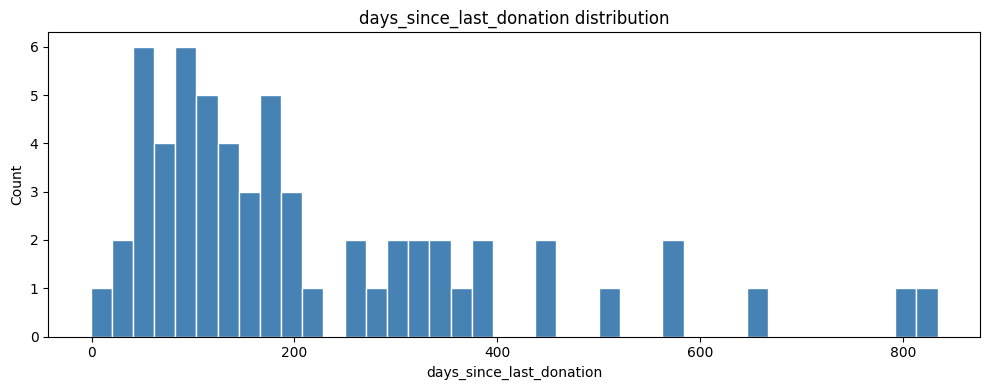


────────────────────────────────────────────────────
  Column  : days_since_first_donation
  Type    : float64  |  Unique: 59
  Count   : 60  |  Missing: 0 (0.0%)
  Range   : -1.0 → 1184.0
  Mean    : 620.6833  |  Median: 603.5  |  Std: 351.239
  Skew    : -0.1414  |  Kurt: -1.232
────────────────────────────────────────────────────


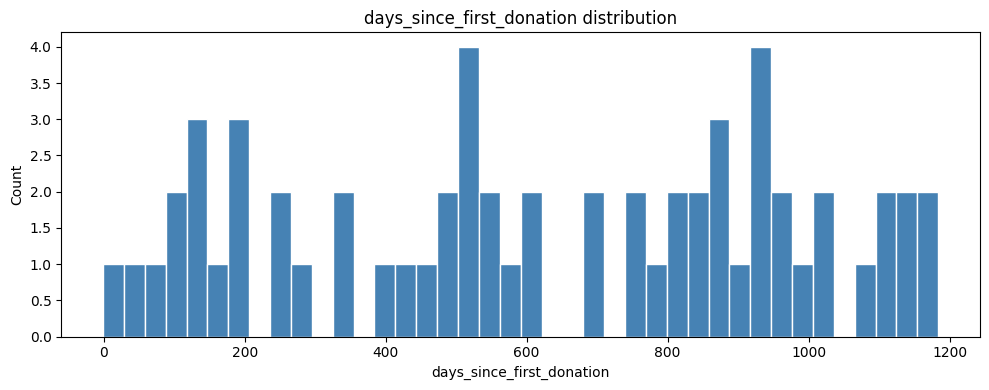


────────────────────────────────────────────────────
  Column  : total_donations
  Type    : int64  |  Unique: 18
  Count   : 60  |  Missing: 0 (0.0%)
  Range   : 0 → 23
  Mean    : 7.0  |  Median: 6.0  |  Std: 4.5696
  Skew    : 1.4906  |  Kurt: 2.5354
  ⚠️  High skew (1.49) — consider transform_skewed_column()
────────────────────────────────────────────────────


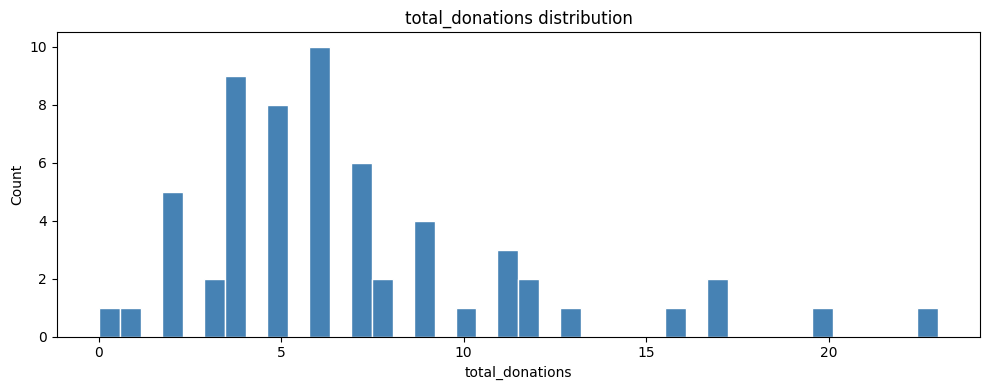

In [38]:
# total_monetary_value and avg_monetary_gift will be heavily right-skewed
# (a few major donors give 10-100x the median). Check and transform.

for col in ['total_monetary_value', 'avg_monetary_gift',
            'days_since_last_donation', 'days_since_first_donation',
            'total_donations']:
    describe_column(df, col)
    plot_distribution(df, col)

In [39]:
# Cap then transform skewed monetary columns (not targets — only features)
# total_monetary_value IS a regression target, so don't transform it.
# avg_monetary_gift is a feature — transform it.

df = cap_outliers_iqr(df, 'avg_monetary_gift')
df = transform_skewed_column(df, 'avg_monetary_gift')
df = cap_outliers_iqr(df, 'total_donations')
df = transform_skewed_column(df, 'total_donations')

[cap_outliers_iqr] 'avg_monetary_gift' — capped 4 outliers (fences: [-164.81, 2102.83]).
[transform_skewed_column] 'avg_monetary_gift' skew=0.423 — below threshold, no transform.
[cap_outliers_iqr] 'total_donations' — capped 4 outliers (fences: [-3.50, 16.50]).
[transform_skewed_column] 'total_donations' — yeo-johnson applied (skew: 1.000 → 0.016).


# Bivariate

## Lapse Prediction (Classification)


  BIVARIATE SUMMARY — target: 'is_lapsed'


  TOP FEATURES FOR 'is_lapsed' (p < 0.05)
                 feature    test      metric  p_value
days_since_last_donation Pearson  r = 0.8280 0.000000
         total_donations Pearson r = -0.3606 0.004653
    total_monetary_value Pearson r = -0.3597 0.004757
 monetary_donation_count Pearson r = -0.3218 0.012152


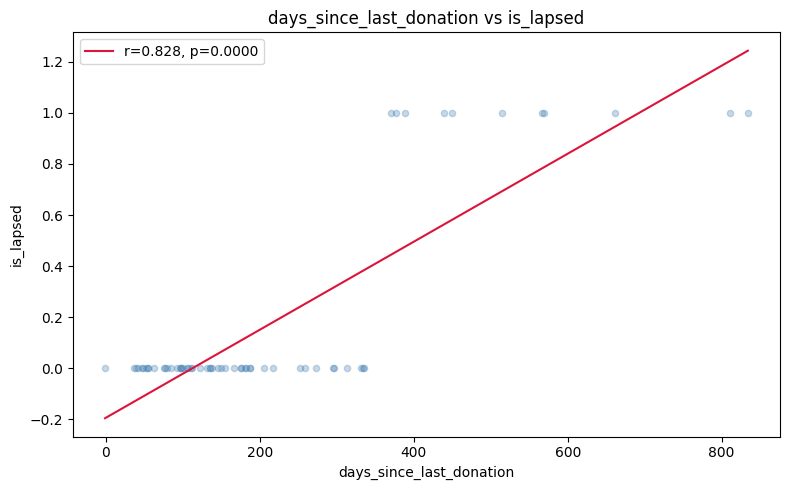

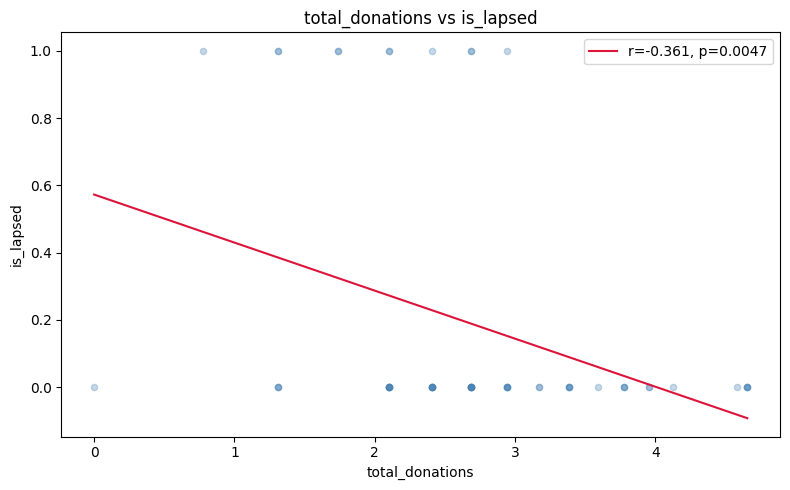

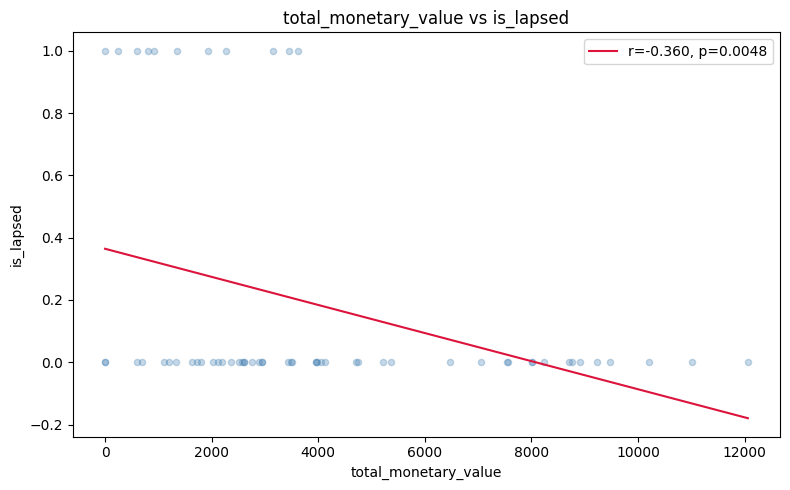

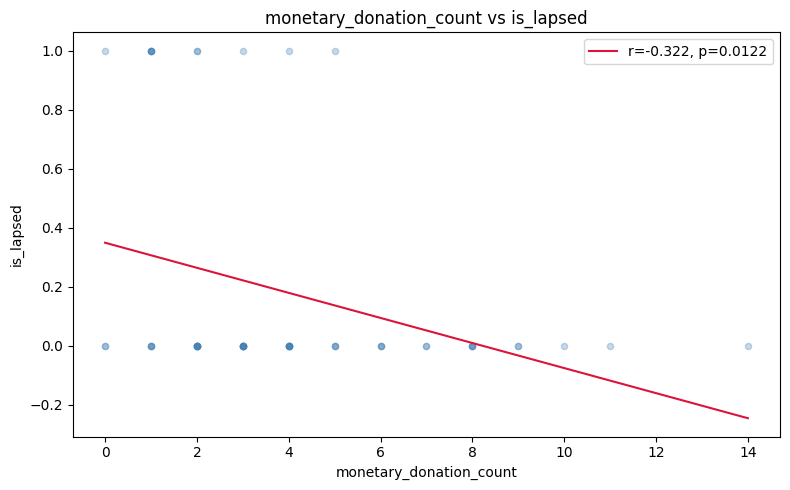

In [40]:
# What predicts whether a donor lapses?
# This is the retention question — the most actionable pipeline.
# Look for: acquisition_channel (how they came in), supporter_type,
# relationship_type (Local vs International), recency signals.

plot_bivariate_summary(df, target='is_lapsed', top_n=15)

## Total Giving (Regression)


  BIVARIATE SUMMARY — target: 'total_monetary_value'


  TOP FEATURES FOR 'total_monetary_value' (p < 0.05)
                 feature    test      metric  p_value
      is_recurring_donor   ANOVA F = 19.5573 0.000044
 monetary_donation_count Pearson  r = 0.8346 0.000000
         total_donations Pearson  r = 0.7645 0.000000
        unique_campaigns Pearson  r = 0.6263 0.000000
       avg_monetary_gift Pearson  r = 0.4392 0.000447
    donation_types_count Pearson  r = 0.4044 0.001351
               is_lapsed Pearson r = -0.3597 0.004757
days_since_last_donation Pearson r = -0.3215 0.012261


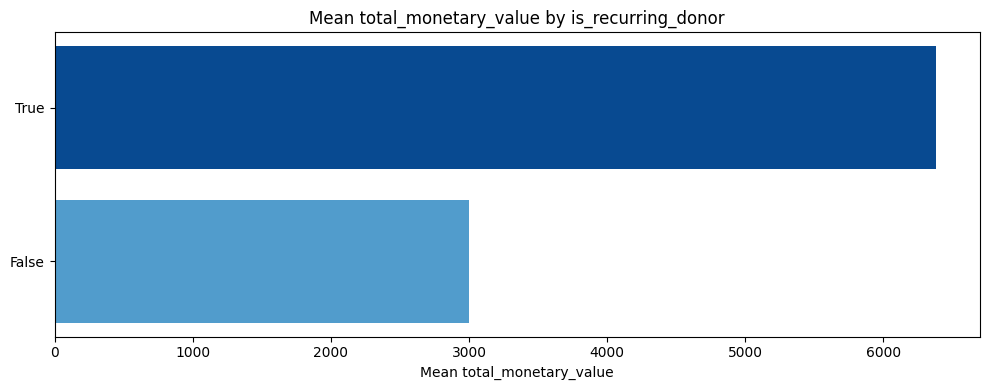

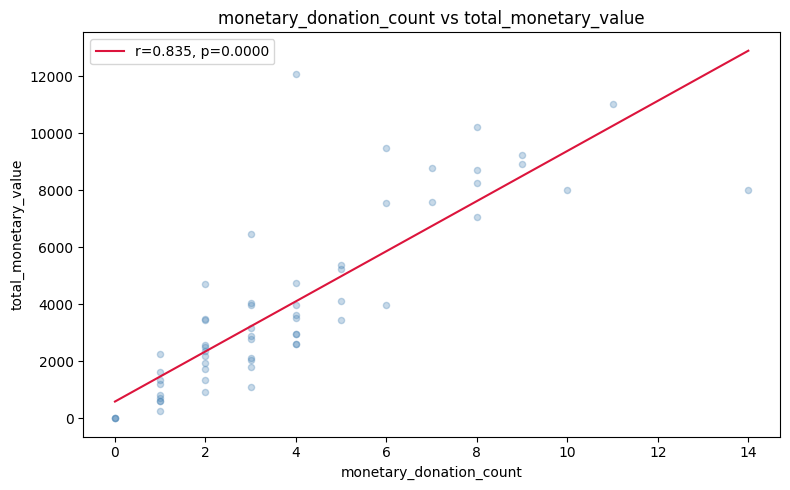

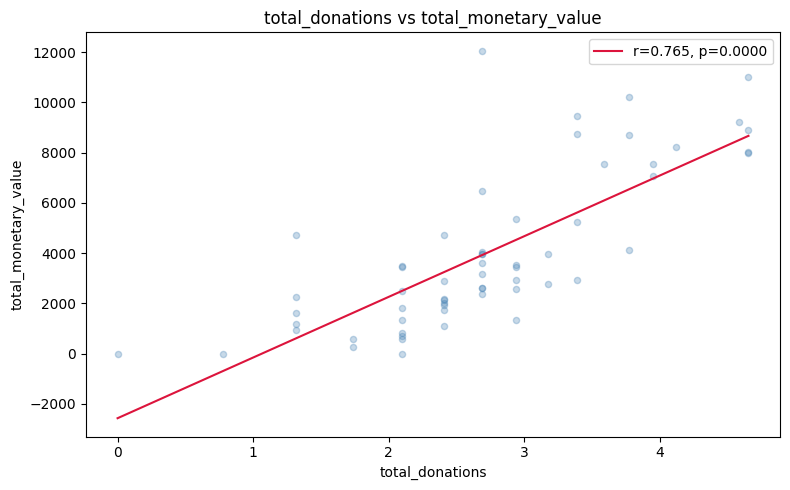

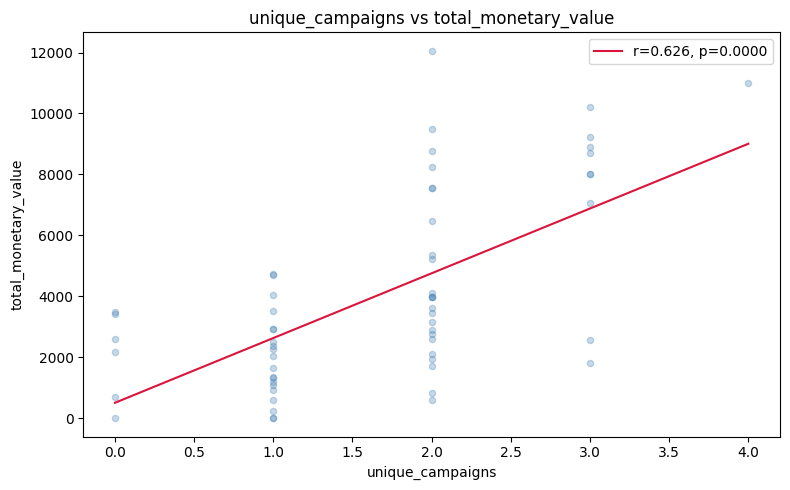

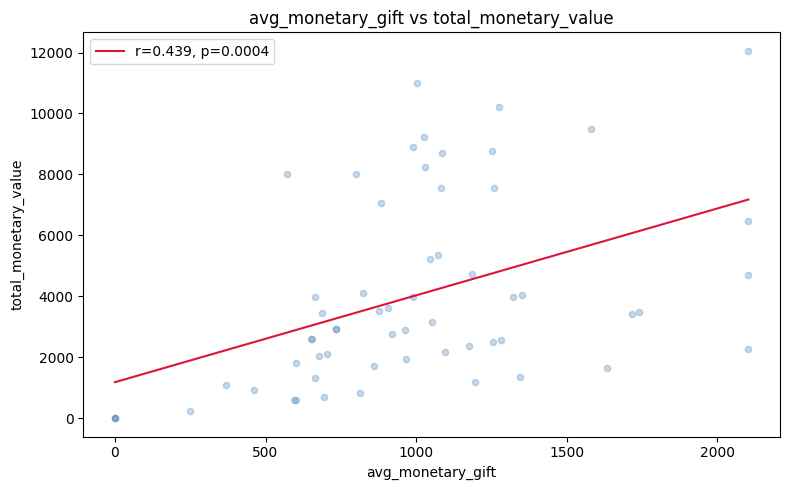

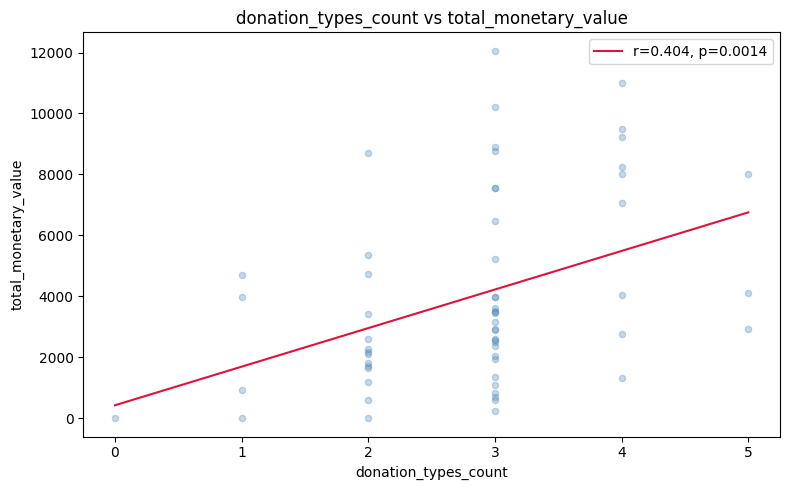

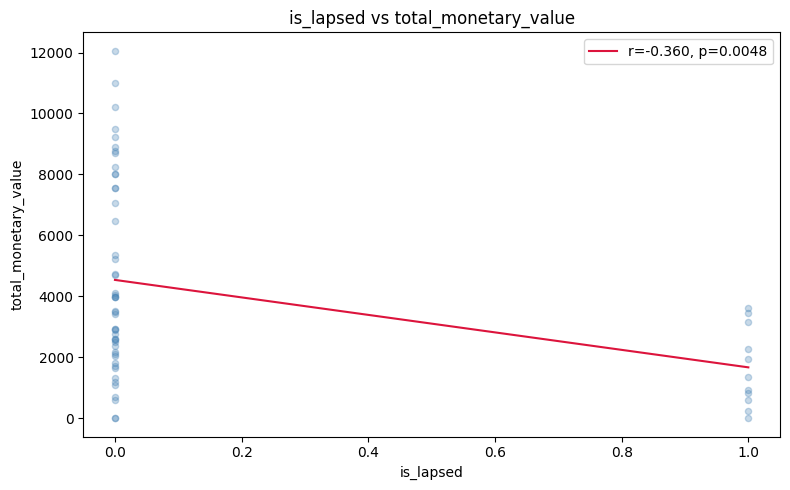

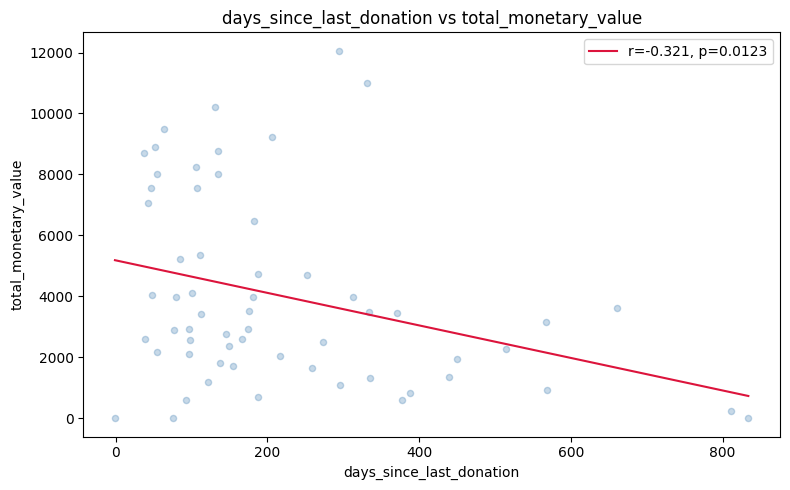

In [41]:
# What predicts total lifetime donation value?
# Useful for segmenting donors and prioritizing outreach.
# Look for: days_since_first_donation (tenure), is_recurring_donor,
# unique_campaigns, acquisition_channel.

plot_bivariate_summary(df, target='total_monetary_value', top_n=15)

## Multicollinearity Check

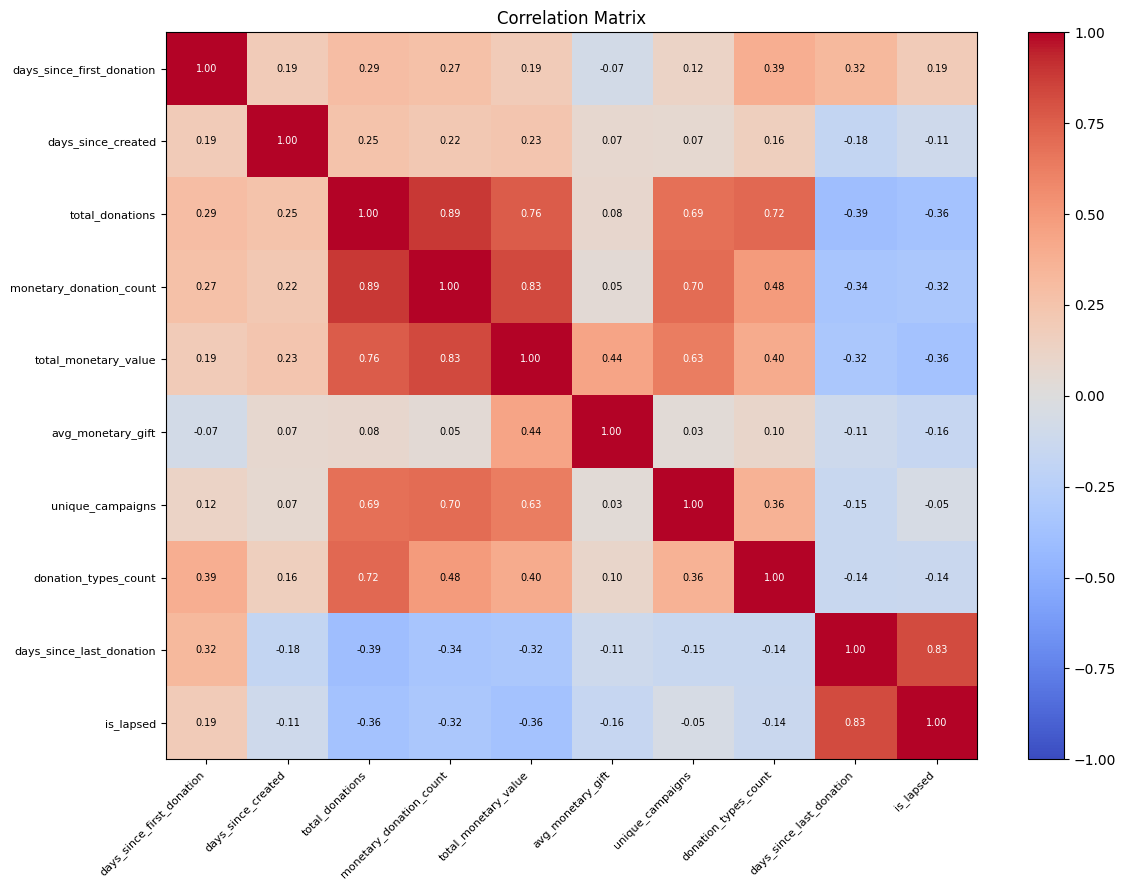

In [42]:
# Check for highly correlated features before finalizing feature lists.
# Expected high-correlation pairs:
#   total_donations ↔ monetary_donation_count (most donations are monetary)
#   total_monetary_value ↔ avg_monetary_gift (mathematically related)
#   days_since_first_donation ↔ days_since_created (similar concept)

numeric_cols = [c for c in df.select_dtypes(include='number').columns]
plot_correlation_heatmap(df, columns=numeric_cols)

In [43]:
corr = get_correlation_matrix(df, columns=numeric_cols, threshold=0.7)


[get_correlation_matrix] Pairs with |r| > 0.7:
  total_donations ↔ monetary_donation_count: r = 0.8873
  total_donations ↔ total_monetary_value: r = 0.7645
  total_donations ↔ donation_types_count: r = 0.7178
  monetary_donation_count ↔ total_monetary_value: r = 0.8346
  days_since_last_donation ↔ is_lapsed: r = 0.8280


# Finalize

## Confirm Feature Lists

In [44]:
NUMERIC_FEATURES = [
    'total_donations',            # how many times they've given
    'monetary_donation_count',    # monetary-specific count
    'avg_monetary_gift',          # average gift size (transformed)
    'unique_campaigns',           # breadth of campaign engagement
    'donation_types_count',       # diversity of giving types
    'days_since_last_donation',   # recency (-1 if never donated)
    'days_since_first_donation',  # tenure (-1 if never donated)
    'days_since_created',         # how long in the system
]

CATEGORICAL_FEATURES = [
    'supporter_type',      # MonetaryDonor, Volunteer, etc.
    'relationship_type',   # Local, International, PartnerOrganization
    'country',             # binned
    'region',              # binned
    'status',              # Active / Inactive
    'acquisition_channel', # Website, SocialMedia, Church, etc.
    'is_recurring_donor',  # boolean → 0/1
]

DROP_ALWAYS = {
    'is_lapsed': [
        # Leaky: lapse is defined by recency, don't also feed in raw recency
        # as a separate feature alongside the engineered target
        'total_monetary_value',  # outcome metric, not a predictor of lapse
        'is_lapsed',             # the target itself
    ],
    'total_monetary_value': [
        'is_lapsed',             # derived from donation behavior
        'monetary_donation_count', # multicollinear with total_donations
    ],
}

print("Feature lists defined.")
print(f"  Numeric:     {len(NUMERIC_FEATURES)}")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)}")

Feature lists defined.
  Numeric:     8
  Categorical: 7


## Save Clean Data

In [45]:
# df.to_csv('data/donors_clean.csv', index=False)
# print(f"Saved: data/donors_clean.csv  ({df.shape[0]} rows × {df.shape[1]} cols)")

## EDA Summary

In [46]:
summary = """
=== DONOR EDA SUMMARY ===

Tables used: supporters.csv + donations.csv
Unit of analysis: one row per supporter (n=60)

DATASET SIZE WARNING:
  Only 60 supporters, 59 with any donation history.
  11 lapsed donors. Models trained on this data will have wide confidence
  intervals. Treat coefficient magnitudes and probabilities with caution.

PII COLUMNS DROPPED:
  display_name, organization_name, first_name, last_name, email, phone

ENGINEERED FEATURES:
  - days_since_first_donation: tenure (-1 for the 1 never-donated supporter)
  - days_since_created: time in system (range: 1262-1557 days)
  - days_since_last_donation: recency (-1 if never donated)
  - monetary_donation_count: monetary gift count (replaces total_donations)
  - total_monetary_value: sum of all monetary gifts in PHP
  - avg_monetary_gift: mean gift size PHP
  - is_recurring_donor: has ever set up a recurring gift
  - unique_campaigns: number of distinct campaigns participated in
  - donation_types_count: diversity of giving types

MULTICOLLINEARITY RESOLVED:
  - total_donations vs monetary_donation_count: r=0.89 -- DROPPED total_donations
  - total_donations vs total_monetary_value: r=0.76
  - total_donations vs donation_types_count: r=0.72
  - monetary_donation_count vs total_monetary_value: r=0.83
  - days_since_last_donation vs is_lapsed: r=0.83 -- LEAKY for lapse target

RARE CATEGORIES BINNED:
  - country: Singapore (1.7%) + Canada (1.7%) -> 'Other'
  - region: all three values above 5%, no binning needed

SKEWED COLUMNS TRANSFORMED:
  - avg_monetary_gift: 4 outliers capped; skew resolved post-cap (0.42, no transform)
  - monetary_donation_count: capped + yeo-johnson applied

TARGET BASE RATES:
  - is_lapsed: 18.3% (11/60 supporters) -- use class_weight='balanced'
  - total_monetary_value: mean=4012 PHP, median=3049 PHP

TOP FEATURES FOR LAPSE:
  1. days_since_last_donation  r=0.83  (LEAKY -- in drop list)
  2. total_donations            r=-0.36 (DROPPED -- multicollinear)
  3. total_monetary_value       r=-0.36 (in drop list for lapse)
  4. monetary_donation_count    r=-0.32
  NOTE: after removing leaky/dropped columns, monetary_donation_count
  and acquisition_channel are the primary actionable predictors

TOP FEATURES FOR TOTAL MONETARY VALUE:
  1. is_recurring_donor         F=19.6  (strongest signal by far)
  2. monetary_donation_count    r=0.83
  3. unique_campaigns           r=0.63
  4. avg_monetary_gift          r=0.44
  5. donation_types_count       r=0.40

KEY INSIGHT:
  Recurring donors give dramatically more over their lifetime (F=19.6).
  This is the most actionable finding: Hearth Haven should prioritize
  converting one-time donors to recurring commitments above all else.
"""
print(summary)


=== DONOR EDA SUMMARY ===

Tables used: supporters.csv + donations.csv
Unit of analysis: one row per supporter (n=60)

DATASET SIZE WARNING:
  Only 60 supporters, 59 with any donation history.
  11 lapsed donors. Models trained on this data will have wide confidence
  intervals. Treat coefficient magnitudes and probabilities with caution.

PII COLUMNS DROPPED:
  display_name, organization_name, first_name, last_name, email, phone

ENGINEERED FEATURES:
  - days_since_first_donation: tenure (-1 for the 1 never-donated supporter)
  - days_since_created: time in system (range: 1262-1557 days)
  - days_since_last_donation: recency (-1 if never donated)
  - monetary_donation_count: monetary gift count (replaces total_donations)
  - total_monetary_value: sum of all monetary gifts in PHP
  - avg_monetary_gift: mean gift size PHP
  - is_recurring_donor: has ever set up a recurring gift
  - unique_campaigns: number of distinct campaigns participated in
  - donation_types_count: diversity of giv